In [2]:
import re, random, io
from pathlib import Path
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# 1. Define your directories in a dictionary for easy iteration
sim_paths = {
    "R20": Path("/home/Ethan/Projects/prec_interactions/data/shear_T800_SR1E7_R20_N4283"),
    "R30": Path("/home/Ethan/Projects/prec_interactions/data/shear_T800_SR1E7_R30_N3350"),
    "R40": Path("/home/Ethan/Projects/prec_interactions/data/shear_T800_SR1E7_R40_N8562")
}

# ----------------------------
# Box & precipitate info
# ----------------------------
xlo, xhi = 0, 299.13675
ylo, yhi = 0, 332.27082
zlo, zhi = 0, 351.07312
box_center = np.array([(xlo+xhi)/2, (ylo+yhi)/2, (zlo+zhi)/2])

In [4]:
def extract_all_thermo_blocks(filepath):
    if not filepath.exists():
        print(f"Warning: {filepath} not found.")
        return pd.DataFrame()
        
    with open(filepath, 'r') as f:
        content = f.read()

    pattern = re.compile(r'(^ +Step +Temp +PotEng.*?\n)(.*?)(?=Loop time|Performance)', re.DOTALL | re.MULTILINE)
    
    all_blocks = []
    for match in pattern.finditer(content):
        header = match.group(1)
        data = match.group(2)
        block_df = pd.read_csv(io.StringIO(header + data), sep=r'\s+')
        all_blocks.append(block_df)

    if not all_blocks:
        return pd.DataFrame()

    full_df = pd.concat(all_blocks, ignore_index=True)
    return full_df.drop_duplicates(subset=['Step']).reset_index(drop=True)

# 2. Process all simulations and store in a dictionary
dfs = {}

# Physical Constants (Assumed same for all for now, update if N changes per sim)
mob_atoms = 2435433
fix_atoms = 456567
xlo, xhi = 0, 299.13675
ylo, yhi = 0, 332.27082
zlo, zhi = 0, 351.07312
vol = (xhi - xlo) * (yhi - ylo) * (zhi - zlo)
vol_rel = (mob_atoms / (mob_atoms + fix_atoms)) * vol
sign_convention = 0.1

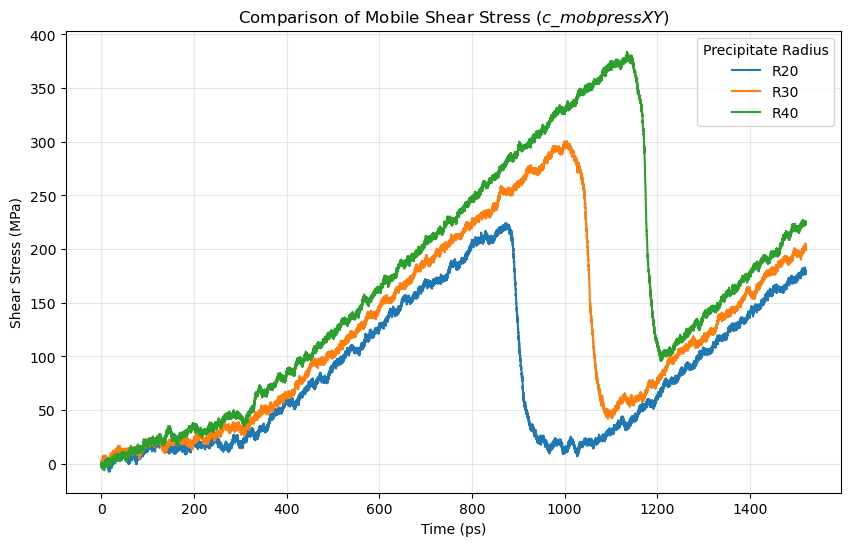

In [12]:
# 3. Load and Process
all_data = []
for label, path in sim_paths.items():
    df = extract_all_thermo_blocks(path / "logs" / "run.log")
    if not df.empty:
        df["Time"] = df["Step"] / 1000
        df["c_mobpressXY"] = (df["c_mobstressXY"] / vol_rel) * sign_convention
        df["Simulation"] = label # Tag for seaborn hue
        all_data.append(df[["Step", "Time", "c_mobpressXY", "Simulation"]])

# Combine into one long-form DataFrame for Seaborn
plot_df = pd.concat(all_data)

# 4. Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=plot_df, x="Time", y="c_mobpressXY", hue="Simulation")

plt.title("Comparison of Mobile Shear Stress ($c\_mobpressXY$)")
plt.xlabel("Time (ps)")
plt.ylabel("Shear Stress (MPa)")
plt.grid(True, alpha=0.3)
plt.legend(title="Precipitate Radius")
plt.show()

<Axes: xlabel='Step', ylabel='Temp'>

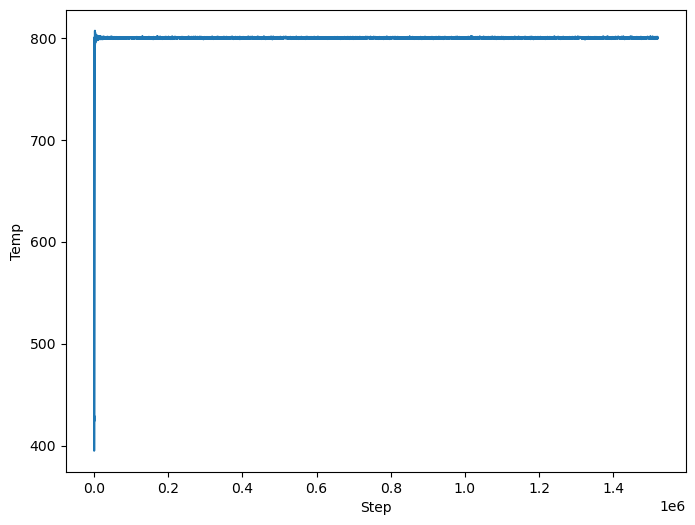

In [13]:
fig, ax = plt.subplots(figsize=(8,6))

sns.lineplot(data=df, x='Step', y='Temp')

In [14]:
plot_df.columns

Index(['Step', 'Time', 'c_mobpressXY', 'Simulation'], dtype='object')

In [15]:
import numpy as np
import pandas as pd

# Only consider data before the dislocation loops
cutoff_step = 1_100_000
filtered_df = plot_df[plot_df["Step"] < cutoff_step]

def snap_step(step, base=10_000):
    """Snap a step to the nearest multiple of 'base'."""
    return int(round(step / base) * base)

results = []

# -----------------------------
# Case 1: Radius 30 at target stresses
# -----------------------------
target_stresses = [100, 150, 200, 250]
df_r30 = filtered_df[filtered_df["Simulation"] == "R30"]

for stress in target_stresses:
    # Pick the row with closest stress
    idx = (df_r30["c_mobpressXY"] - stress).abs().idxmin()
    row = df_r30.loc[idx]

    # Snap step to nearest 10,000
    snapped_step = snap_step(row["Step"])

    results.append({
        "Radius": 30,
        "TargetStress": stress,
        "ActualStress": row["c_mobpressXY"],
        "Step": snapped_step,
        "Time": row["Time"]
    })

# -----------------------------
# Case 2: Stress 150 for all radii
# -----------------------------
target_stress = 150
for sim in ["R20", "R30", "R40"]:
    df_sim = filtered_df[filtered_df["Simulation"] == sim]
    idx = (df_sim["c_mobpressXY"] - target_stress).abs().idxmin()
    row = df_sim.loc[idx]
    
    snapped_step = snap_step(row["Step"])
    radius = int(sim.replace("R", ""))

    results.append({
        "Radius": radius,
        "TargetStress": target_stress,
        "ActualStress": row["c_mobpressXY"],
        "Step": snapped_step,
        "Time": row["Time"]
    })

# Create a DataFrame
interest_df = pd.DataFrame(results).sort_values(["Radius", "TargetStress"]).reset_index(drop=True)
interest_df

,Radius,TargetStress,ActualStress,Step,Time
0,20,150,149.982927,670000,668.2
1,30,100,99.993080,490000,488.2
2,30,150,149.999305,610000,605.9
3,30,150,149.999305,610000,605.9
4,30,200,199.998275,740000,742.3
5,30,250,250.000519,870000,873.8
6,40,150,149.940563,580000,576.6


In [16]:
results = []

for _, row in interest_df.iterrows():

    radius = int(row["Radius"])
    step = int(row["Step"])
    
    sim_key = f"R{radius}"
    sim_path = sim_paths[sim_key]

    # ----------------------------
    # Load simulation summary
    # ----------------------------
    summary_path = sim_path / "analysis" / "simulation_summary.csv"
    summary_df = pd.read_csv(summary_path)

    idx = (summary_df["timestep"] - step).abs().idxmin()
    summary_row = summary_df.loc[idx]

    dislocation_length = summary_row["length"]

    # ----------------------------
    # Find closest DXA file
    # ----------------------------
    dxa_dir = sim_path / "dxa_verts"
    
    dxa_steps = []
    for f in dxa_dir.glob("dxa_*.csv"):
        s = int(f.stem.split("_")[1])
        dxa_steps.append((s, f))
    
    # find nearest DXA step
    closest_dxa = min(dxa_steps, key=lambda x: abs(x[0] - step))

    dxa_step = closest_dxa[0]
    dxa_file = closest_dxa[1]

    results.append({
        "Radius": radius,
        "TargetStress": row["TargetStress"],
        "ActualStress": row["ActualStress"],
        "Step": step,
        "DXA_step": dxa_step,
        "DXA_file": str(dxa_file),
        "DislocationLength": dislocation_length
    })


analysis_points_df = pd.DataFrame(results)

analysis_points_df

,Radius,TargetStress,ActualStress,Step,DXA_step,DXA_file,DislocationLength
0,20,150.0,149.982927,670000,670000,/home/Ethan/Projects/prec_interactions/data/sh...,396.795909
1,30,100.0,99.993080,490000,490000,/home/Ethan/Projects/prec_interactions/data/sh...,364.972752
2,30,150.0,149.999305,610000,610000,/home/Ethan/Projects/prec_interactions/data/sh...,384.354918
3,30,150.0,149.999305,610000,610000,/home/Ethan/Projects/prec_interactions/data/sh...,384.354918
4,30,200.0,199.998275,740000,740000,/home/Ethan/Projects/prec_interactions/data/sh...,411.585638
5,30,250.0,250.000519,870000,870000,/home/Ethan/Projects/prec_interactions/data/sh...,441.600045
6,40,150.0,149.940563,580000,580000,/home/Ethan/Projects/prec_interactions/data/sh...,382.083759


In [17]:
def load_dxa_vertices(file_path):
    """
    Load DXA vertices CSV and return numpy array of shape (N, 3)
    columns: z, x, y
    """
    df = pd.read_csv(file_path)
    vertices = df[['z', 'x', 'y']].to_numpy()
    return vertices

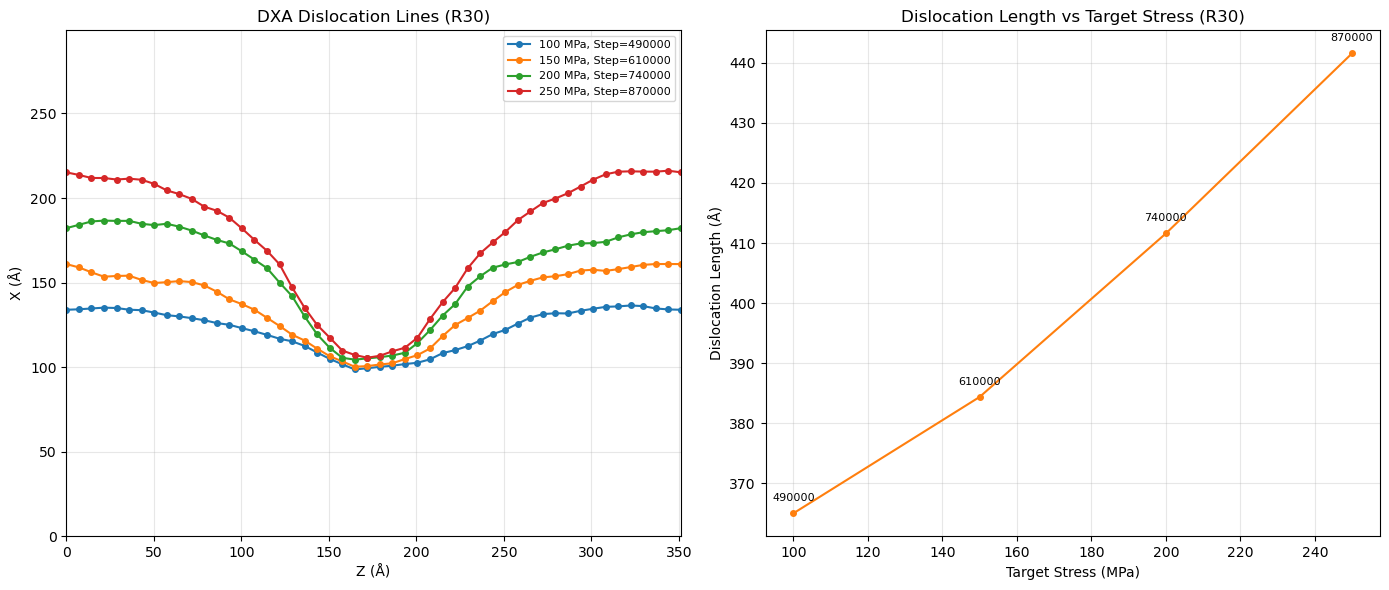

In [18]:
import matplotlib.pyplot as plt

# Filter for R30 from the analysis DataFrame
df_r30 = analysis_points_df[analysis_points_df["Radius"] == 30].copy()

# Standardize column names: strip whitespace, replace spaces, lowercase
df_r30.columns = df_r30.columns.str.strip().str.replace(" ", "_").str.lower()

# Drop duplicates by target_stress and step
df_r30_unique = df_r30.drop_duplicates(subset=["targetstress", "step"])

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# ---------------------------------------------------
# Left: DXA vertices for R30 (different stress)
# ---------------------------------------------------
ax1 = axes[0]
for _, row in df_r30_unique.iterrows():
    vertices = pd.read_csv(row["dxa_file"])[['z','x']].to_numpy()
    z = vertices[:,0]
    x = vertices[:,1]
    ax1.plot(z, x, '-o', markersize=4, label=f"{row['actualstress']:.0f} MPa, Step={int(row['step'])}")

ax1.set_xlabel("Z (Å)")
ax1.set_ylabel("X (Å)")
ax1.set_title("DXA Dislocation Lines (R30)")
ax1.set_xlim([zlo, zhi])
ax1.set_ylim([xlo, xhi])
ax1.grid(alpha=0.3)
ax1.legend(fontsize=8)

# ---------------------------------------------------
# Right: Dislocation length vs TargetStress (R30)
# ---------------------------------------------------
ax2 = axes[1]
ax2.plot(df_r30_unique["targetstress"], df_r30_unique["dislocationlength"], '-o', color='tab:orange', markersize=4)
for _, row in df_r30_unique.iterrows():
    ax2.text(row["targetstress"], row["dislocationlength"] + 2, f"{int(row['step'])}", ha='center', fontsize=8)

ax2.set_xlabel("Target Stress (MPa)")
ax2.set_ylabel("Dislocation Length (Å)")
ax2.set_title("Dislocation Length vs Target Stress (R30)")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

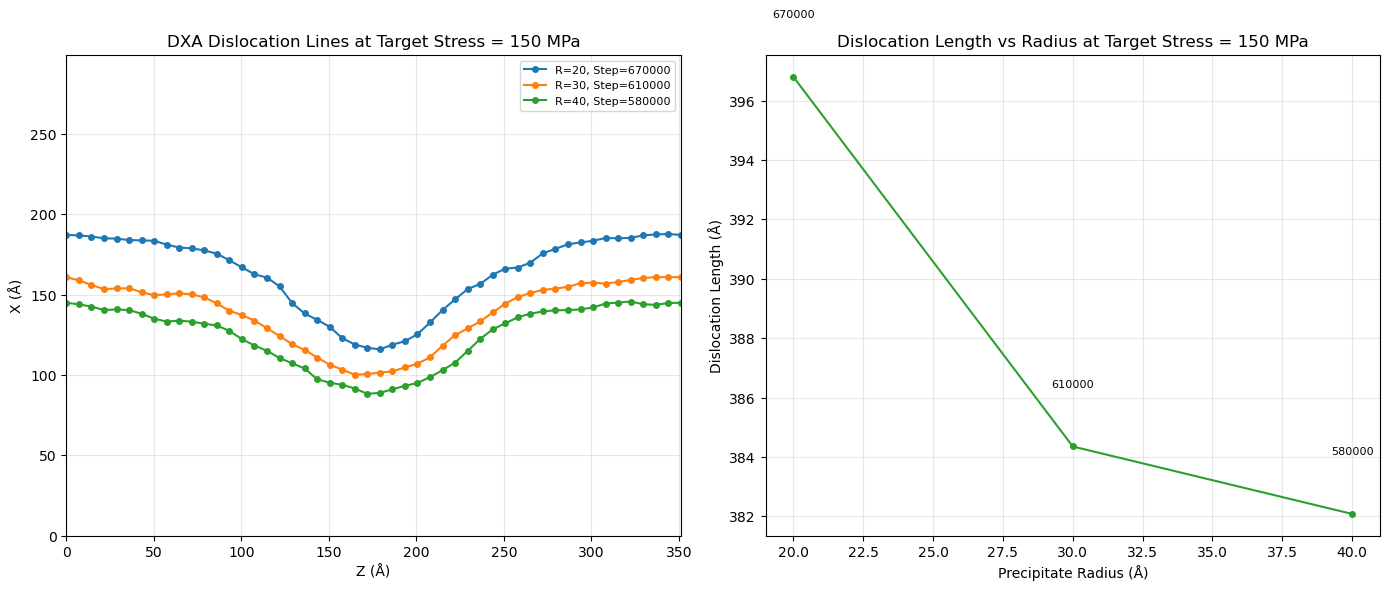

In [19]:
# Filter for a specific TargetStress
target_stress = 150
df_stress = analysis_points_df[analysis_points_df["TargetStress"] == target_stress]

# Drop duplicates by Radius and Step to avoid double counting
df_stress_unique = df_stress.drop_duplicates(subset=["Radius", "Step"])

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# ---------------------------------------------------
# Left: DXA vertices for fixed TargetStress (different radii)
# ---------------------------------------------------
ax1 = axes[0]
for _, row in df_stress_unique.iterrows():
    vertices = pd.read_csv(row["DXA_file"])[['z','x']].to_numpy()
    z = vertices[:,0]
    x = vertices[:,1]
    ax1.plot(z, x, '-o', label=f"R={int(row['Radius'])}, Step={int(row['Step'])}", markersize=4)

ax1.set_xlabel("Z (Å)")
ax1.set_ylabel("X (Å)")
ax1.set_title(f"DXA Dislocation Lines at Target Stress = {target_stress} MPa")
ax1.grid(alpha=0.3)
ax1.legend(fontsize=8)
ax1.set_xlim([zlo, zhi])
ax1.set_ylim([xlo, xhi])

# ---------------------------------------------------
# Right: Dislocation length vs Radius (fixed stress)
# ---------------------------------------------------
ax2 = axes[1]
ax2.plot(df_stress_unique["Radius"], df_stress_unique["DislocationLength"], '-o', color='tab:green', markersize=4)
for _, row in df_stress_unique.iterrows():
    ax2.text(row["Radius"], row["DislocationLength"] + 2, f"{int(row['Step'])}", ha='center', fontsize=8)

ax2.set_xlabel("Precipitate Radius (Å)")
ax2.set_ylabel("Dislocation Length (Å)")
ax2.set_title(f"Dislocation Length vs Radius at Target Stress = {target_stress} MPa")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
def generate_sia_cloud(vertices, prec_radius, num_sias=150,
                       R_sia_min=5, R_sia_max=10, min_spacing=None,
                       min_spacing_fallback_factor=0.5,
                       max_attempts_per_sia=1000, seed=None,
                       box_bounds=None):
    """
    Stratified SIA placement with auto-spacing and two-pass fallback.
    
    min_spacing: if None, auto-calculated from shell volume and num_sias.
                 If provided, used as the primary spacing; fallback will be
                 min_spacing * min_spacing_fallback_factor.
    min_spacing_fallback_factor: fraction of primary spacing used in second pass.
    """
    if seed is not None:
        np.random.seed(seed)
    if box_bounds is None:
        raise ValueError("box_bounds must be provided")

    xlo, xhi = box_bounds[0]
    ylo, yhi = box_bounds[1]
    zlo, zhi = box_bounds[2]
    Lx = xhi - xlo
    Lz = zhi - zlo
    box_center = np.array([(xlo+xhi)/2, (ylo+yhi)/2, (zlo+zhi)/2])

    # --- Auto-calculate min_spacing from shell volume if not provided ---
    if min_spacing is None:
        shell_volume = (4/3) * np.pi * (R_sia_max**3 - R_sia_min**3)
        # Target ~30% packing fraction (conservative for random placement)
        vol_per_sia = shell_volume * 0.30 / num_sias
        min_spacing = 2 * (3 * vol_per_sia / (4 * np.pi)) ** (1/3)
        print(f"Auto min_spacing: {min_spacing:.1f} Å")

    fallback_spacing = min_spacing * min_spacing_fallback_factor
    print(f"Primary spacing: {min_spacing:.1f} Å | Fallback spacing: {fallback_spacing:.1f} Å")

    # --- MIC distance (periodic x, z only) ---
    def mic_dists(candidate, existing):
        diffs = existing - candidate
        diffs[:, 0] -= Lx * np.round(diffs[:, 0] / Lx)
        diffs[:, 2] -= Lz * np.round(diffs[:, 2] / Lz)
        return np.linalg.norm(diffs, axis=1)

    # --- Arc-length parameterisation ---
    seg_vecs = vertices[1:] - vertices[:-1]
    seg_lengths = np.linalg.norm(seg_vecs, axis=1)
    cumulative = np.concatenate([[0], np.cumsum(seg_lengths)])
    total_length = cumulative[-1]

    bin_size = total_length / num_sias
    jitter = np.random.uniform(-0.5, 0.5, size=num_sias) * bin_size
    arc_positions = np.clip((np.arange(num_sias) + 0.5) * bin_size + jitter, 0, total_length)

    def arc_to_point(s):
        idx = np.clip(np.searchsorted(cumulative, s, side='right') - 1, 0, len(seg_lengths) - 1)
        t = (s - cumulative[idx]) / seg_lengths[idx] if seg_lengths[idx] > 0 else 0
        return vertices[idx] + t * seg_vecs[idx]

    def try_place(anchor, spacing):
        for _ in range(max_attempts_per_sia):
            r = np.random.uniform(R_sia_min, R_sia_max)
            theta = np.random.uniform(0, 2 * np.pi)
            cos_phi = np.random.uniform(-1, 1)
            sin_phi = np.sqrt(1 - cos_phi**2)
            candidate = anchor + np.array([
                r * sin_phi * np.cos(theta),
                r * sin_phi * np.sin(theta),
                r * cos_phi
            ])
            # Wrap x and z only
            candidate[0] = ((candidate[0] - xlo) % Lx) + xlo
            candidate[2] = ((candidate[2] - zlo) % Lz) + zlo

            if np.linalg.norm(candidate - box_center) < prec_radius:
                continue
            if len(sias) > 0 and np.any(mic_dists(candidate, np.array(sias)) < spacing):
                continue
            return candidate
        return None

    # --- Pass 1: primary spacing ---
    sias = []
    failed_anchors = []
    for s in arc_positions:
        anchor = arc_to_point(s)
        result = try_place(anchor, min_spacing)
        if result is not None:
            sias.append(result)
        else:
            failed_anchors.append(anchor)

    print(f"Pass 1: placed {len(sias)}/{num_sias} | Failed bins: {len(failed_anchors)}")

    # --- Pass 2: relaxed spacing for failed bins ---
    if failed_anchors:
        recovered = 0
        for anchor in failed_anchors:
            result = try_place(anchor, fallback_spacing)
            if result is not None:
                sias.append(result)
                recovered += 1
        print(f"Pass 2: recovered {recovered}/{len(failed_anchors)} with spacing={fallback_spacing:.1f} Å")

    if len(sias) < num_sias:
        print(f"Warning: final count {len(sias)}/{num_sias} SIAs placed")

    return np.array(sias)

In [21]:
# Dictionary to store SIA clouds
# Key = (Radius, TargetStress, Step)
# Value = np.array of SIA positions
sias_dict = {}

# Parameters for SIA placement
safety_buffer = 5  # Å beyond precipitate radius

for _, row in analysis_points_df.iterrows():
    radius = int(row["Radius"])
    target_stress = row["TargetStress"]
    step = int(row["Step"])
    
    # Load DXA vertices
    vertices = pd.read_csv(row["DXA_file"])[['x','y','z']].to_numpy()
    
    # Prec forbidden radius = precipitate radius + safety buffer
    prec_radius = radius + safety_buffer
    
    # Generate SIAs around the dislocation line
    sias_cloud = generate_sia_cloud(
        vertices, 
        prec_radius=prec_radius, 
        num_sias=200,          # total number of SIAs to place
        R_sia_min=25,           # min distance from dislocation line
        R_sia_max=125,          # max distance from dislocation line
        min_spacing=40.0,       # minimum spacing between SIAs
        seed=100,               # for reproducibility
        box_bounds=[(xlo, xhi),(ylo, yhi),(zlo, zhi)]   # <-- pass the box bounds here
    )
    
    # Store the cloud in the dictionary
    sias_dict[(radius, target_stress, step)] = sias_cloud
    
    print(f"R={radius}, Stress={target_stress}: Placed {len(sias_cloud)} SIAs")

Primary spacing: 40.0 Å | Fallback spacing: 20.0 Å
Pass 1: placed 188/200 | Failed bins: 12
Pass 2: recovered 12/12 with spacing=20.0 Å
R=20, Stress=150.0: Placed 200 SIAs
Primary spacing: 40.0 Å | Fallback spacing: 20.0 Å
Pass 1: placed 185/200 | Failed bins: 15
Pass 2: recovered 15/15 with spacing=20.0 Å
R=30, Stress=100.0: Placed 200 SIAs
Primary spacing: 40.0 Å | Fallback spacing: 20.0 Å
Pass 1: placed 182/200 | Failed bins: 18
Pass 2: recovered 18/18 with spacing=20.0 Å
R=30, Stress=150.0: Placed 200 SIAs
Primary spacing: 40.0 Å | Fallback spacing: 20.0 Å
Pass 1: placed 182/200 | Failed bins: 18
Pass 2: recovered 18/18 with spacing=20.0 Å
R=30, Stress=150.0: Placed 200 SIAs
Primary spacing: 40.0 Å | Fallback spacing: 20.0 Å
Pass 1: placed 189/200 | Failed bins: 11
Pass 2: recovered 11/11 with spacing=20.0 Å
R=30, Stress=200.0: Placed 200 SIAs
Primary spacing: 40.0 Å | Fallback spacing: 20.0 Å
Pass 1: placed 193/200 | Failed bins: 7
Pass 2: recovered 7/7 with spacing=20.0 Å
R=30, S

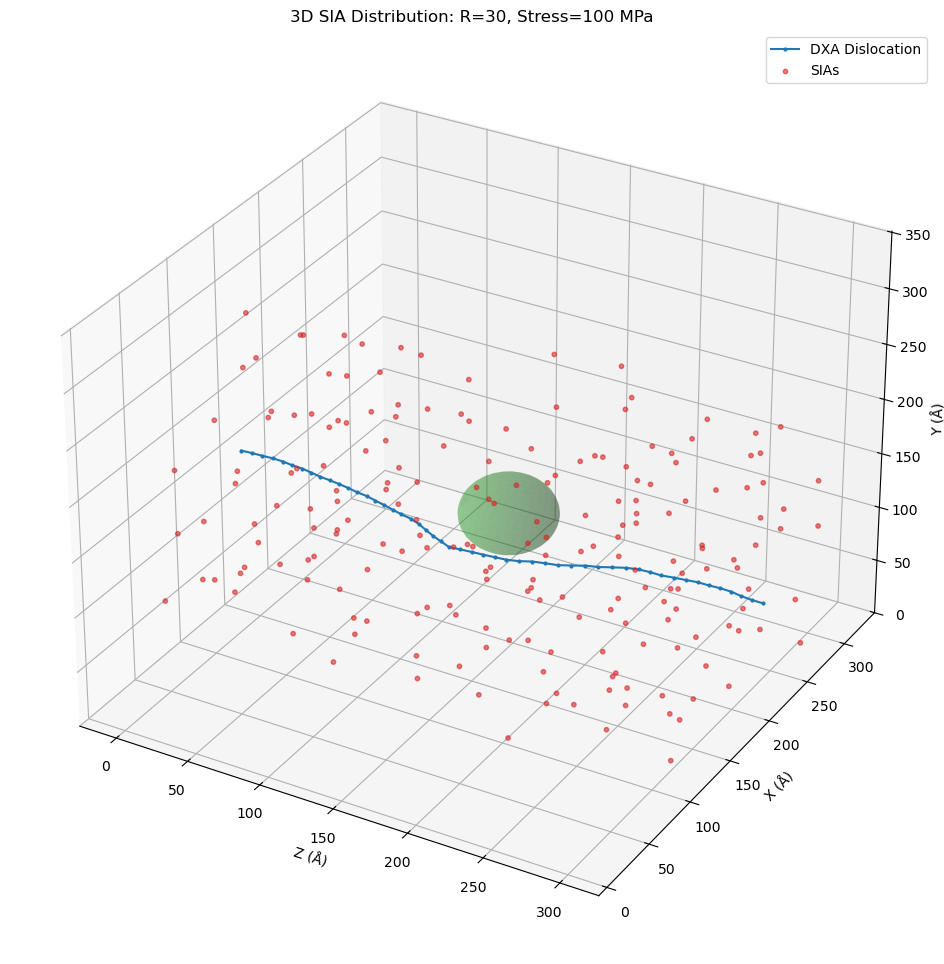

In [22]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Choose a configuration to visualize
# -----------------------------
radius_to_plot = 30
stress_to_plot = 100
row = analysis_points_df[
    (analysis_points_df["Radius"] == radius_to_plot) & 
    (analysis_points_df["TargetStress"] == stress_to_plot)
].iloc[0]

vertices = pd.read_csv(row["DXA_file"])[['x','y','z']].to_numpy()  # full XYZ
sias = sias_dict[(radius_to_plot, stress_to_plot, int(row["Step"]))]

# -----------------------------
# 3D Plot
# -----------------------------
fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(111, projection='3d')

# DXA dislocation line
ax.plot(vertices[:,2], vertices[:,0], vertices[:,1], '-o', color='tab:blue', label="DXA Dislocation", markersize=2)  

# SIA positions
ax.scatter(sias[:,2], sias[:,0], sias[:,1], s=10, color='tab:red', alpha=0.6, label="SIAs")

# Precipitate as a semi-transparent sphere
u, v = np.mgrid[0:2*np.pi:40j, 0:np.pi:20j]
prec_x = box_center[0] + radius_to_plot * np.cos(u) * np.sin(v)
prec_y = box_center[1] + radius_to_plot * np.sin(u) * np.sin(v)
prec_z = box_center[2] + radius_to_plot * np.cos(v)
ax.plot_surface(prec_z, prec_x, prec_y, color='tab:green', alpha=0.3, linewidth=0, antialiased=True)

# Labels and title
ax.set_xlabel("Z (Å)")
ax.set_ylabel("X (Å)")
ax.set_zlabel("Y (Å)")
ax.set_title(f"3D SIA Distribution: R={radius_to_plot}, Stress={stress_to_plot} MPa")

# -----------------------------
# Force equal aspect ratio
# -----------------------------
max_range = np.array([xhi-xlo, yhi-ylo, zhi-zlo]).max() / 2.0
mid_x = (xhi + xlo) * 0.5
mid_y = (yhi + ylo) * 0.5
mid_z = (zhi + zlo) * 0.5

ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

ax.legend()
plt.show()

In [23]:
import json
from pathlib import Path
import numpy as np

# --- Configuration ---
# These are only used to LOCATE files during the generation phase
# The metadata saved will NOT contain these absolute paths.
project_root_local = Path.home() / "Projects/prec_interactions"
base_data_dir_local = project_root_local / "data"

original_strain_rate = "1E7" 
source_temp = 800  # Restarts pulled from 800K simulations

# --- Workflow ---
for _, row in analysis_points_df.iterrows():
    radius = int(row["Radius"])
    target_stress = row["TargetStress"]
    step = int(row["Step"])
    
    # Calculate the nearest 10k step for the restart file
    restart_step = int(round(step / 10_000) * 10_000)
    restart_file_name = f"{restart_step}.restart"

    # SIA cloud lookup
    key = (radius, target_stress, step)
    if key not in sias_dict:
        print(f"Warning: No SIAs for R={radius}, Stress={target_stress}, Step={step}")
        continue
    sias = sias_dict[key]

    # Determine rerun temperatures
    temps = [700, 800, 900] if (radius == 30 and target_stress == 150) else [800]

    # 1. Dynamically find the SOURCE shear directory
    search_pattern = f"shear_T{source_temp}_SR{original_strain_rate}_R{radius}_N*"
    matching_dirs = list(base_data_dir_local.glob(search_pattern))

    if not matching_dirs:
        print(f"Skipping: No T{source_temp} source directory found for R{radius}")
        continue
    
    sim_dir_local = matching_dirs[0]
    folder_name = sim_dir_local.name 

    for temp in temps:
        # 2. Setup the rerun directory locally
        rerun_case_name = f"R{radius}_S{int(target_stress)}_T{temp}"
        rerun_dir_local = base_data_dir_local / "rerun" / rerun_case_name
        rerun_dir_local.mkdir(parents=True, exist_ok=True)

        # 3. Save atoms.txt
        atom_file = rerun_dir_local / "atoms.txt"
        np.savetxt(atom_file, sias, fmt="%.6f")

        # 4. Save Portable Metadata
        # We use paths relative to the 'data' directory
        metadata = {
            "Radius": radius,
            "TargetStress": target_stress,
            "Step": step,
            "Temperature": temp,
            "SourceTemperature": source_temp,
            "NumSIAs": len(sias),
            
            # KEY CHANGE: RELATIVE PATHS
            # These point to the file relative to the 'prec_interactions/data' folder
            "RestartFile_rel": f"{folder_name}/restart/{restart_file_name}",
            "AtomsFile_rel": f"rerun/{rerun_case_name}/atoms.txt",
            "OriginalSimDir_rel": folder_name,
            
            "BoxBounds": {
                "x": [row.get("xlo", 0), row.get("xhi", 0)],
                "y": [row.get("ylo", 0), row.get("yhi", 0)],
                "z": [row.get("zlo", 0), row.get("zhi", 0)]
            }
        }

        meta_file = rerun_dir_local / "metadata.json"
        with open(meta_file, "w") as f:
            json.dump(metadata, f, indent=2)

        print(f"Success: Prepared {rerun_case_name} (Source: {folder_name})")

Success: Prepared R20_S150_T800 (Source: shear_T800_SR1E7_R20_N4283)
Success: Prepared R30_S100_T800 (Source: shear_T800_SR1E7_R30_N3350)
Success: Prepared R30_S150_T700 (Source: shear_T800_SR1E7_R30_N3350)
Success: Prepared R30_S150_T800 (Source: shear_T800_SR1E7_R30_N3350)
Success: Prepared R30_S150_T900 (Source: shear_T800_SR1E7_R30_N3350)
Success: Prepared R30_S150_T700 (Source: shear_T800_SR1E7_R30_N3350)
Success: Prepared R30_S150_T800 (Source: shear_T800_SR1E7_R30_N3350)
Success: Prepared R30_S150_T900 (Source: shear_T800_SR1E7_R30_N3350)
Success: Prepared R30_S200_T800 (Source: shear_T800_SR1E7_R30_N3350)
Success: Prepared R30_S250_T800 (Source: shear_T800_SR1E7_R30_N3350)
Success: Prepared R40_S150_T800 (Source: shear_T800_SR1E7_R40_N8562)
